## Plot ISOMIP+ test case results

- transect of temperature and salinity (need e variable for this! default z variable is just from sea surface/ice-ocean interface so wrong in cavities)
- melt rate map

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import netCDF4 as nc
import cmocean as cm

from xgcm import Grid

In [3]:
#define some files
basee = '/g/data/x77/cy8964/idealised-mom6-control/'
def open_files(label):
    base = basee 
    prog = xr.open_dataset(base + label+'/archive/output000/ave_prog.nc', decode_timedelta = True)
    return prog
def open_ice(label):
    base = basee 
    prog = xr.open_dataset(base + label+'/archive/output000/ice.nc', decode_timedelta = True)
    return prog
def open_forcing(label):
    base = basee 
    prog = xr.open_dataset(base + label+'/archive/output000/forcing.nc', decode_timedelta = True)
    return prog
def plot_t(ax,yy0,tt,variable,varname,vmin1,vmax1,cmap,ymax): #boundaries are u cell grid https://gist.github.com/adcroft/dde8d3fafd77d0caaa5613e64f1d7eff
    prog = open_files(label)
    ocean_static = xr.open_dataset(basee + label +'/archive/output000/ocean_geometry.nc')
    prog.zl.attrs['c_grid_axis_shift'] = 0
    prog.zi.attrs['c_grid_axis_shift'] = -0.5
    prog.xh.attrs['c_grid_axis_shift'] = 0
    prog.xq.attrs['c_grid_axis_shift'] = -0.5
    prog.yh.attrs['c_grid_axis_shift'] = 0
    prog.yq.attrs['c_grid_axis_shift'] = -0.5

    grid = Grid(prog,coords={"x":{"center":"xh","outer":"xq"},
                             "y":{"center":"yh","outer":"yq"},
                             "z":{"center":"zl","outer":"zi"}},periodic=False,autoparse_metadata=False)
    file_name = label
    depth = grid.interp(prog.e,"x", boundary="extend").isel(Time = tt).bfill('xq').ffill('xq').bfill('yh').ffill('yh')
    lon = depth*0 + depth.xq
    dataplot = variable.isel(Time = tt)

    levels = np.linspace(vmin1, vmax1, 51)
    cax = ax.pcolormesh(lon[:,yy0,...],depth[:,yy0,...],dataplot[:,yy0,:],vmin = vmin1, vmax = vmax1, cmap = cmap)
    if (varname == "uo"):
        cbar = plt.colorbar(cax, ax = ax, label = " ")
        cbar.formatter.set_powerlimits((0, 0))
        cbar.formatter.set_useMathText(True)
        cbar.ax.yaxis.set_offset_position('right')
        cbar.update_ticks()

    else:
        plt.colorbar(cax, ax = ax, label = varname)
    ## plot interface heights
    i_heights = depth # this is 'Interface Height Relative to Mean Sea Level' interpolated to u
    i_heights = i_heights.isel(yh = yy0)#.mean('xh')

    # plot a line of layer depths, layer by layer
    nz = len(i_heights.zi)
    xq = prog.xq

#    for i in range(nz):
#        ax.plot(xq,i_heights[i], color = 'k', linewidth = 0.2)
    
    ax.set_ylim(ymin=-ymax,ymax=0)
    ax.set_ylabel('Depth (m)')
    ax.set_xlabel('x (km)')
    ax.set_title(varname+' , ' +label)

/jobfs/166930901.gadi-pbs/ipykernel_3905180/4142766497.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  prog = xr.open_dataset(base + label+'/archive/output000/ave_prog.nc', decode_timedelta = True)
/jobfs/166930901.gadi-pbs/ipykernel_3905180/4142766497.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  prog = xr.open_dataset(base + label+'/archive/output000/ave_prog.nc', decode_timedelta = True)
/jobfs/166930901.gadi-pbs/ipykernel_3905180/4142766497.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior refo

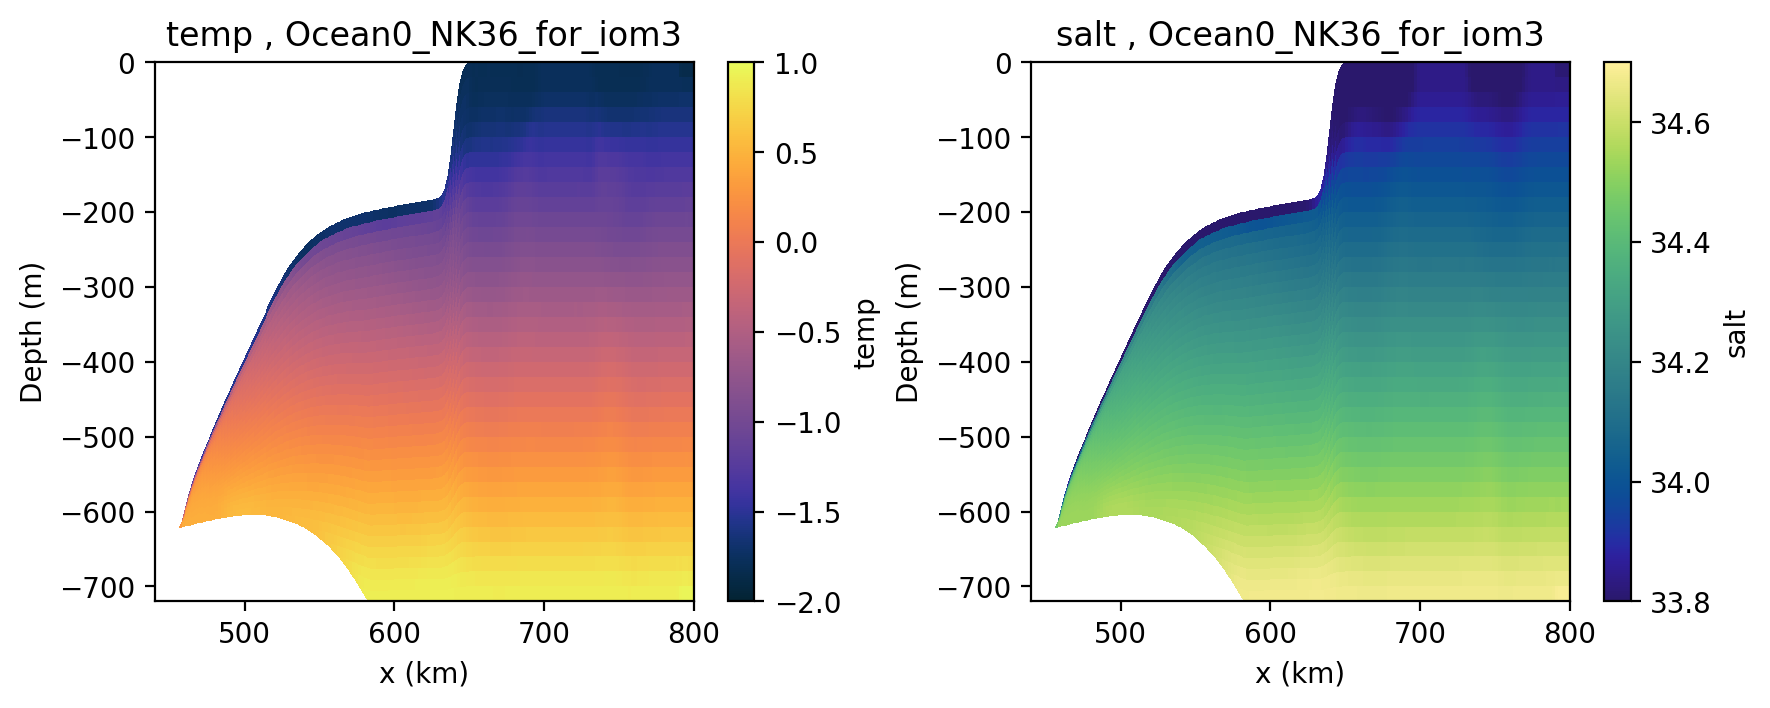

In [6]:
fig, axes = plt.subplots(ncols = 2, nrows = 1, figsize = (10,3.5),dpi = 200)
# define expt
label = 'Ocean0_NK36_for_iom3'
prog = open_files(label)
# choose centre transect (x = 20) and max depth of 720m
x = 20
ymax = 720
time = -1 #last time

plot_t(axes[0],x,time,prog.temp,"temp",-2,1,cm.cm.thermal,ymax)
axes[0].set_xlim(440,800)
plot_t(axes[1],x,time,prog.salt,"salt",33.8,34.7,cm.cm.haline,ymax)
axes[1].set_xlim(440,800)

fig.subplots_adjust(wspace = 0.3)

plt.show()

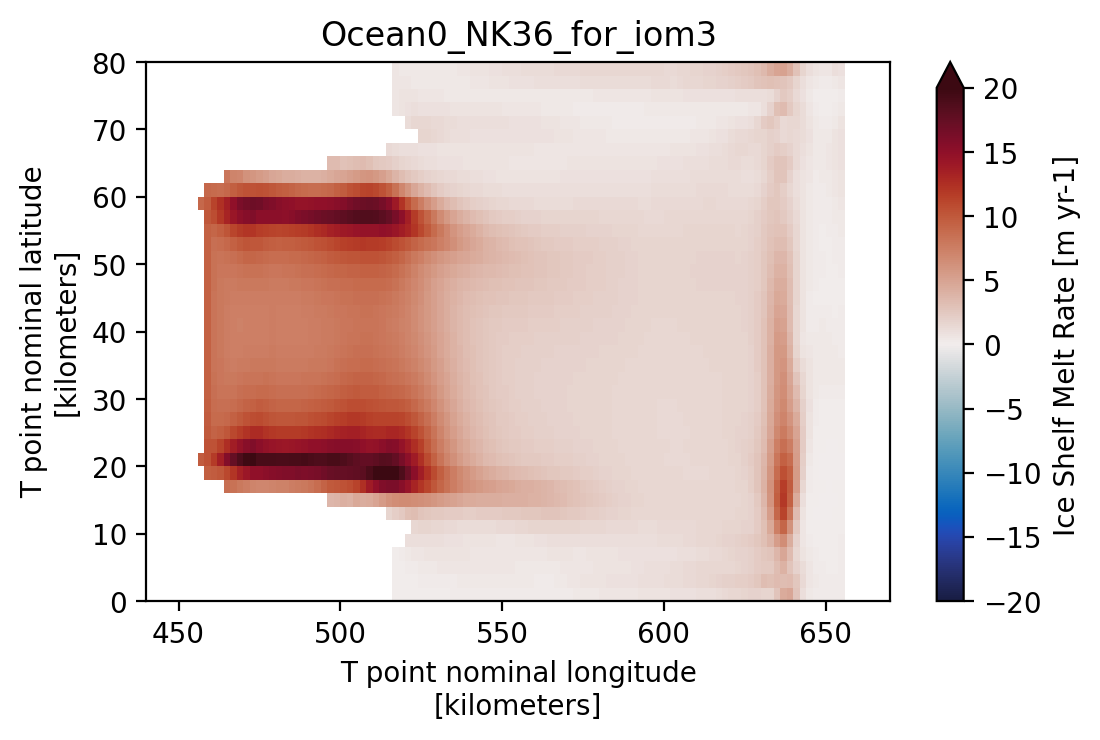

In [8]:
fig, axes = plt.subplots(figsize = (6,3.5),dpi = 200)

# define expt
label = 'Ocean0_NK36_for_iom3'
vmax = 20 #m/yr
a = axes

ice = open_ice(label)
ice.melt_rate.isel(Time = -1).where(ice.melt_rate.isel(Time = -1)!=0).plot(ax = a, vmax = vmax, vmin = -vmax, cmap = cm.cm.balance)
a.set_title(label)
a.set_xlim(440,670)

plt.show()
